In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Biblioteca Pandas, series y dataframes

Pandas es una biblioteca de Python muy usada para análisis y manipulación de datos. Provee principalmente dos tipos de clases para trabajar con datos:

- **Series:** un vector unidimensional indexado, que contiene datos de cualquier tipo
como números enteros, cadenas, objetos Python, etc.

- **DataFrame:** una estructura de datos bidimensional que contiene datos como una matriz bidimensional o una tabla con filas y columnas.

Bibliografía recomendada: Sección 5 de Python for Data Analysis, de Wes McKinney (creador de la biblioteca Pandas), disponible on-line en forma gratuita en la página
https://wesmckinney.com/book/pandas-basics

## Series

Las series de Pandas son vectores similares a los arrays de NumPy, que podemos indexar usando etiquetas.

#### **Ejercicio:** 
Crear la siguiente Series, observar qué devuelve `values` e `index` e interpretar.

In [3]:
enteros = pd.Series([7,4,-5,3])
enteros

0    7
1    4
2   -5
3    3
dtype: int64

In [6]:
type(enteros.values) # Los valores de una serie se tratan como arrays de numpy

numpy.ndarray

In [5]:
enteros.index # Por default, los índices van de 0 a N-1.

RangeIndex(start=0, stop=4, step=1)

Podemos asignar etiquetas (o índices) a cada valor de la serie.

In [7]:
reales = pd.Series([np.pi,0,-2,1.41], index = ["a", "b", "c", "d"])
display(reales)

a    3.141593
b    0.000000
c   -2.000000
d    1.410000
dtype: float64

In [8]:
display(reales.values)
display(reales.index)

array([ 3.14159265,  0.        , -2.        ,  1.41      ])

Index(['a', 'b', 'c', 'd'], dtype='str')

Para acceder a los elementos podemos usar las etiquetas.

In [10]:
print(reales["a"])

3.141592653589793


In [11]:
# Para acceder a los elementos mediante su posición, no se hace de esta forma
reales[1]

KeyError: 1

In [12]:
# Para acceder por su posición usamos iloc
reales.iloc[1]

np.float64(0.0)

In [13]:
# Podemos usar también rangos
reales.iloc[1:3]

b    0.0
c   -2.0
dtype: float64

In [14]:
# Para acceder por etiquetas podemos usar también loc
# Observar que para rangos de etiquetas sí incluye la última etiqueta
reales.loc["a":"c"]

a    3.141593
b    0.000000
c   -2.000000
dtype: float64

In [15]:
# Podemos definir labels numericos
temperaturas = pd.Series([15, 17, 18.2, 25], index = np.array([5, 10, 15, 20]))
print(temperaturas)

5     15.0
10    17.0
15    18.2
20    25.0
dtype: float64


In [16]:
# Que esperamos de los siguientes comandos?
print(temperaturas.iloc[1:3])
print(temperaturas.loc[10:20]) # Por qué??

10    17.0
15    18.2
dtype: float64
10    17.0
15    18.2
20    25.0
dtype: float64


In [17]:
type(temperaturas.index)

pandas.Index

In [19]:
# Funcionará? --> NO, porque los indices son de tipo Index, no es un valor númerico normal de posición
temperaturas.iloc[10]

IndexError: single positional indexer is out-of-bounds

In [20]:
temperaturas.loc[10]

np.float64(17.0)

In [21]:
# Podemos seleccionar elementos mediante una lista de etiquetas
realesSub = reales[["a","b"]]
print(realesSub)
print(realesSub.index)

a    3.141593
b    0.000000
dtype: float64
Index(['a', 'b'], dtype='str')


### Operaciones con series
Las operaciones que pueden aplicarse a numpy arrays pueden aplicarse también a series de Pandas, conservando los índices.

In [22]:
reales

a    3.141593
b    0.000000
c   -2.000000
d    1.410000
dtype: float64

In [23]:
np.exp(reales)

a    23.140693
b     1.000000
c     0.135335
d     4.095955
dtype: float64

In [24]:
reales * 3

a    9.424778
b    0.000000
c   -6.000000
d    4.230000
dtype: float64

In [25]:
reales > 1

a     True
b    False
c    False
d     True
dtype: bool

In [27]:
reales[reales > 1] # Es como cuando filtraba un array de numpy

a    3.141593
d    1.410000
dtype: float64

¿Qué esperamos que dé este código?

In [28]:
print(enteros)
print(reales)

0    7
1    4
2   -5
3    3
dtype: int64
a    3.141593
b    0.000000
c   -2.000000
d    1.410000
dtype: float64


In [29]:
enteros + reales

0   NaN
1   NaN
2   NaN
3   NaN
a   NaN
b   NaN
c   NaN
d   NaN
dtype: float64

NaN significa "not a number", se utiliza en series de Pandas para valores faltantes (missing values).

In [30]:
# Y ahora?
enteros2 = pd.Series([1,2,3,4], index = ["d", "b", "y", "z"])
enteros2

d    1
b    2
y    3
z    4
dtype: int64

In [31]:
suma = reales + enteros2
suma

a     NaN
b    2.00
c     NaN
d    2.41
y     NaN
z     NaN
dtype: float64

**Vemos que solo se suman los valores valores en las filas con índices que aparecen en las dos series.** 

In [32]:
# Los floats de Numyp aceptan el valor np.nan. 
# Qué resultados esperamos?
print(3 + np.nan)
print(0 * np.nan)
print(np.nan - np.nan)

nan
nan
nan


Las series de Pandas tienen varias funciones útiles que iremos viendo más adelante. A modo de ejemplo, interpretar qué hacen las siguientes funciones.

In [33]:
series1 = pd.Series(["a", "b", "c", "b", "a", "c", "x"])
series1

0    a
1    b
2    c
3    b
4    a
5    c
6    x
dtype: str

In [35]:
series1.isin(["b", "c"]) # Evalua si el elemento de la seríe pertenece a un conjunto dado

0    False
1     True
2     True
3     True
4    False
5     True
6    False
dtype: bool

In [37]:
# Qué hace este método? -> Cuenta la cantidad de repeticiones de un mismo elemento
series1.value_counts()

a    2
b    2
c    2
x    1
Name: count, dtype: int64

In [39]:
# Ejercicio: cómo me quedo solo con las filas con etiquetas "b" o "c"?

series1[series1.isin(["b","c"])]


1    b
2    c
3    b
5    c
dtype: str

## DataFrames
Un data frame es una representación de los datos en formato de tabla en la que cada
columna son vectores del mismo tamaño. Como cada columna es un vector, cada columna puede
contener datos de un único tipo. Se pueden pensar como variables. Cada variable corresponde a una
serie de Pandas, y **todas las series de un dataframe están indexadas por los mismos índices**.

Una forma de crear un data frame es utilizando un "diccionario". Todas las variables del
diccionario deben ser vectores o listas de la misma longitud. 

In [5]:
data = {"nombres": ["Rodrigo", "Sergio", "Cristina", "Diana"], "altura": np.array([178, 172, 175, 168]), "peso": np.array([81.2, 76.1, 68.5, 64.0])}
display(data)

{'nombres': ['Rodrigo', 'Sergio', 'Cristina', 'Diana'],
 'altura': array([178, 172, 175, 168]),
 'peso': array([81.2, 76.1, 68.5, 64. ])}

In [6]:
type(data)

dict

In [7]:
data["peso"]

array([81.2, 76.1, 68.5, 64. ])

In [8]:
# Creamos un data frame con esos datos. Cuáles son los índices? -> Los indices se van a poner automaticamente, por defecto van del 0 en adelante.
pacientes = pd.DataFrame(data)
pacientes

,nombres,altura,peso
0,Rodrigo,178,81.2
1,Sergio,172,76.1
2,Cristina,175,68.5
3,Diana,168,64.0


In [9]:
# En este ejemplo podemos usar los nombres como índices
pacientes = pd.DataFrame(data).set_index("nombres")
display(pacientes)

,altura,peso
nombres,,
Rodrigo,178,81.2
Sergio,172,76.1
Cristina,175,68.5
Diana,168,64.0


In [10]:
# Podemos acceder a las columnas de dos formas distintas
alturas = pacientes["altura"]
alturas

nombres
Rodrigo     178
Sergio      172
Cristina    175
Diana       168
Name: altura, dtype: int64

In [11]:
# Esto a veces es más práctico, pero hay que tener cuidado que el nombre usado no tenga otro significado o símbolos o espacios
pacientes.altura

nombres
Rodrigo     178
Sergio      172
Cristina    175
Diana       168
Name: altura, dtype: int64

In [12]:
type(alturas)

pandas.Series

In [13]:
alturas.dtype

dtype('int64')

A diferencia de las matrices en Numpy, un DataFrame de Pandas es un conjunto de columnas, no de filas. 
Si queremos saber la altura de Rodrigo, pensar cuál de los dos comandos será correcto antes de ejecutarlos.

In [16]:
pacientes["Rodrigo"].altura # Esto no va a funcionar porque es como que estoy queriendo acceder a una columna denominada "Rodrigo"

KeyError: 'Rodrigo'

In [17]:
pacientes["altura"].Rodrigo # La forma correcta es esta 

np.int64(178)

Para acceder a una fila de un dataframe, podemos usar los métodos `loc[]` y `iloc[]`. 

¿Cómo se usan? ¿Cuál es la diferencia entre los dos comandos? ¿Que tipo de dato nos devuelve?

In [27]:
pacientes.loc["Rodrigo"] # .loc es para obtener la fila del dataframe con la etiqueta 

altura    178.0
peso       81.2
Name: Rodrigo, dtype: float64

In [22]:
pacientes.iloc[0] # .iloc funciona con el índice numérico, no le puedo pasar la etiqueta que puse como indice

altura    178.0
peso       81.2
Name: Rodrigo, dtype: float64

In [26]:
# Tanto .loc como .iloc devuelven series de Pandas
print(type(pacientes.loc["Rodrigo"]))
print(type(pacientes.iloc[0]))

<class 'pandas.Series'>
<class 'pandas.Series'>


## Archivos de datos

La biblioteca Pandas nos permite trabajar fácilmente con archivos de datos.
1. Leer el archivo casos_coronavirus.csv .
2. Graficar la curva de casos por día.
3. Graficar la curva de casos acumulados.
4. Definir log_cum_casos como el logaritmo de la cantidad de casos acumulados y graficar en función de la cantidad de días transcurridos.
5. Estimar, tomando dos valores, la pendiente de la recta para los datos a partir del dia 30.
6. Graficar la recta estimada junto con los datos. ¿Consideran que es una buena estimación?


In [29]:
df = pd.read_csv("data/casos_coronavirus.csv") # DataFrame
df.head()  # Primeras filas del DataFrame

,fecha,confirmados_Nuevos
0,3-3-2020,1
1,4-3-2020,0
2,5-3-2020,1
3,6-3-2020,6
4,7-3-2020,0


In [30]:
# Información básica del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   fecha               96 non-null     str  
 1   confirmados_Nuevos  96 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.6 KB


In [32]:
# ¿Cómo usamos la fecha como índice?
df = pd.read_csv("data/casos_coronavirus.csv").set_index("fecha")
df

,confirmados_Nuevos
fecha,
3-3-2020,1
4-3-2020,0
5-3-2020,1
6-3-2020,6
7-3-2020,0
...,...
2-6-2020,904
3-6-2020,949
4-6-2020,929


<Axes: xlabel='fecha'>

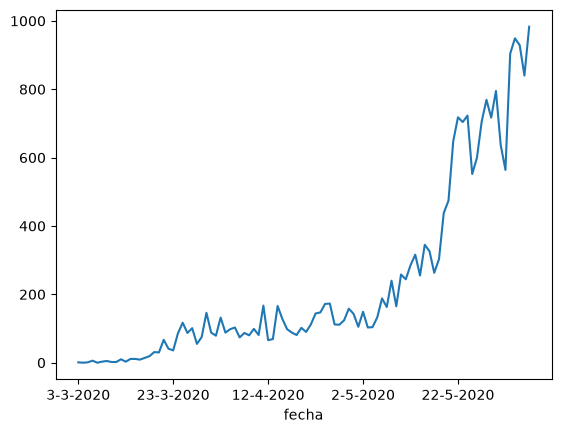

In [33]:
# Graficamos utilizando el método plot de series de Pandas
df["confirmados_Nuevos"].plot()

<Axes: xlabel='fecha'>

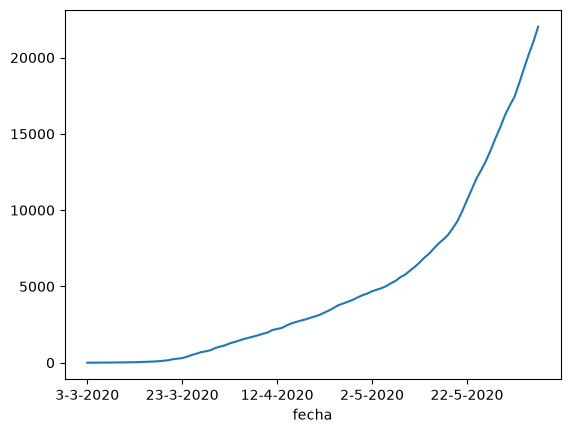

In [34]:
# Queremos graficar los casos acumulados, podemos usar el método cumsum() de series Pandas
df.confirmados_Nuevos.cumsum().plot()

#### **Ejercicio** 
Esta serie presenta un crecimiento exponencial. 
Queremos tomar logaritmos para linealizar, ¿como podemos hacerlo?


<Axes: xlabel='fecha'>

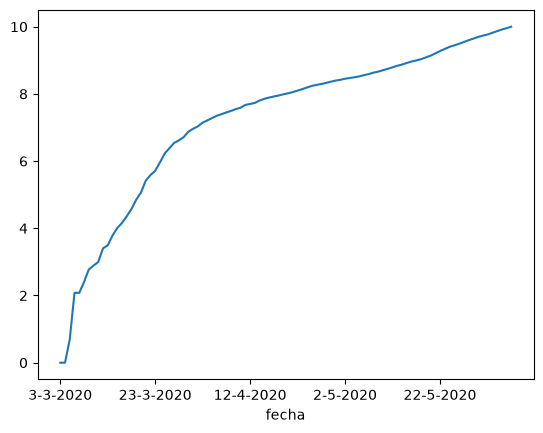

In [36]:
log_cum_casos = np.log(df.confirmados_Nuevos.cumsum())
log_cum_casos.plot()

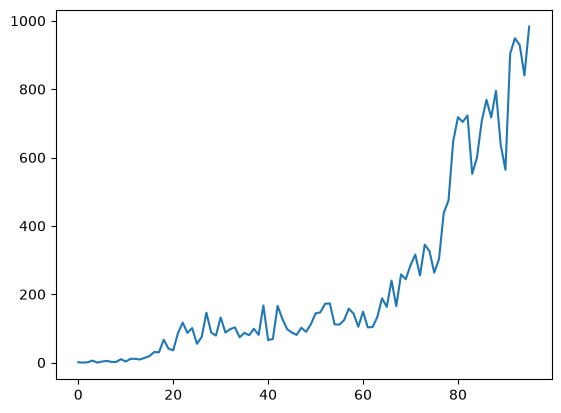

In [40]:
casos = df.reset_index(drop = True)  # Reseteamos índices para ver mejor el gráfico y estimar mejor la pendiente.
plt.plot(casos)

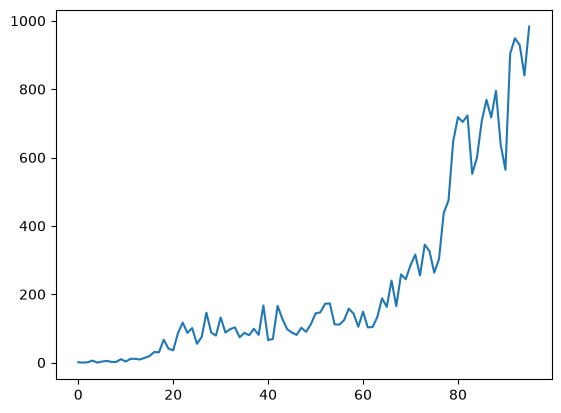

In [43]:
casos = df.reset_index(drop = True)  # Reseteamos índices para ver mejor el gráfico y estimar mejor la pendiente.
plt.plot(casos)  # No es tan bueno para manejar los ticks de fechas

# Agregamos la recta
x_recta = 20
y_recta = 2
plt.plot(x_recta, y_recta)

## Gapminder

A modo de ejemplo, vamos a explorar el dataset Gapminder que contiene datos poblacionales y de desarrollo humano de distintos países a lo largo del tiempo.

**Aclaración:** en el notebook original te hace instalar la librería gapminder, pero esta necesita de otra librería que se llama _pkg_resources_ que a su vez viene en otra librería que se llama _setuptools_. El problema es que _pkg_resources_ quedó obsoleta a partir de la v82 de _setuptools_, por lo que si se quiere usar gapminder instalando la librería, se tiene que insatalar una versión obsoleta de setuptools usando _pip install "setuptools<82"_. En este notebook y los próximos se va a descargar el dataset de gapminder directo desde la página para evitar el problema de las librerías.  

In [4]:
# Descarga de gapminder directo desde internet
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

In [49]:
# Verificamos si se cargo correctamente
display(gapminder)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


**Pregunta:** Podemos usar alguna columna como índice? --> Podríamos usar la de pais

In [50]:
# Para ver las primeras cinco filas
gapminder.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


Podemos ver información básica del DataFrame con la función info

In [51]:
gapminder.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   str    
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 80.0 KB


In [52]:
# Vemos todos los países en la base
gapminder["country"].unique() # .unique trae todos los valores del dataset sin duplicados

<StringArray>
[       'Afghanistan',            'Albania',            'Algeria',
             'Angola',          'Argentina',          'Australia',
            'Austria',            'Bahrain',         'Bangladesh',
            'Belgium',
 ...
             'Uganda',     'United Kingdom',      'United States',
            'Uruguay',          'Venezuela',            'Vietnam',
 'West Bank and Gaza',         'Yemen Rep.',             'Zambia',
           'Zimbabwe']
Length: 142, dtype: str

In [53]:
# Cuántos países son?
gapminder["country"].nunique()

142

#### Entrada en calor

1. Cuál era la población de Argentina en 1967? Y la de Brasil?
2. En qué países la expectativa de vida era mayor que 80 años en 2002? Y en 1997? (filtrar la tabla para dejar solo las filas correspondientes)
   

In [75]:
# 1) Argentina

gapminder[(gapminder["country"] == "Argentina") & (gapminder["year"] == 1967)]

,country,year,pop,continent,lifeExp,gdpPercap
51,Argentina,1967,22934225.0,Americas,65.634,8052.953021


In [79]:
# 1) Brasil

gapminder[(gapminder["country"] == "Brazil") & (gapminder["year"] == 1967)]

,country,year,pop,continent,lifeExp,gdpPercap
171,Brazil,1967,88049823.0,Americas,57.632,3429.864357


In [81]:
# 2) En 2002

gapminder[(gapminder["lifeExp"] > 80) & (gapminder["year"] == 2002)]

,country,year,pop,continent,lifeExp,gdpPercap
70,Australia,2002,19546792.0,Oceania,80.370,30687.75473
670,Hong Kong China,2002,6762476.0,Asia,81.495,30209.01516
694,Iceland,2002,288030.0,Europe,80.500,31163.20196
778,Italy,2002,57926999.0,Europe,80.240,27968.09817
802,Japan,2002,127065841.0,Asia,82.000,28604.59190
1474,Sweden,2002,8954175.0,Europe,80.040,29341.63093
1486,Switzerland,2002,7361757.0,Europe,80.620,34480.95771


In [83]:
# 2) En 1997

gapminder[(gapminder["lifeExp"] > 80) & (gapminder["year"] == 1997)]

,country,year,pop,continent,lifeExp,gdpPercap
801,Japan,1997,125956499.0,Asia,80.69,28816.58499


### groupby

In [84]:
# Si queremos ver cuántos países hay en cada continente...
# podemos agrupar por continente y ver el tamaño de cada grupo
gapminder.groupby("continent").size()    # Para un dataframe agrupado, size es un método!

continent
Africa      624
Americas    300
Asia        396
Europe      360
Oceania      24
dtype: int64

In [85]:
# Pero cada país aparece varias veces, con datos de distintos años.
# Para contar sin repeticion usamos nuevamente nunique
cantidades = gapminder.groupby("continent")["country"].nunique()
cantidades

continent
Africa      52
Americas    25
Asia        33
Europe      30
Oceania      2
Name: country, dtype: int64

In [86]:
# Que tipo de dato nos devolvió? Cómo está indexado? -> Devuelve un entero con la cantidad de valores que hay dentro del grupo Africa
cantidades["Africa"]

np.int64(52)

In [88]:
# Si queremos calcular porcentajes, dividimos por la cantidad total de paises
totalPaises = gapminder["country"].nunique()
print(totalPaises)
gapminder.groupby("continent")["country"].nunique() / totalPaises

142


continent
Africa      0.366197
Americas    0.176056
Asia        0.232394
Europe      0.211268
Oceania     0.014085
Name: country, dtype: float64

### value_counts

In [89]:
# O podemos usar el comando value_counts y pasarle un parámetro para que nos de los valores normalizados.
# (la normalización lleva la suma total a 1)
gapminder[["continent", "country"]].drop_duplicates().continent.value_counts(normalize=True)

continent
Africa      0.366197
Asia        0.232394
Europe      0.211268
Americas    0.176056
Oceania     0.014085
Name: proportion, dtype: float64

In [90]:
# Vemos todos los años disponibles
gapminder["year"].unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [91]:
# Tenemos datos de todos los países todos los años?
# Agrupamos los datos por año y calculamos el tamaño de cada bloque
gapminder.groupby("year").size()

year
1952    142
1957    142
1962    142
1967    142
1972    142
1977    142
1982    142
1987    142
1992    142
1997    142
2002    142
2007    142
dtype: int64

In [100]:
# Ejercicio: cómo podemos hacerlo utilizando value_counts?
gapminder[["year", "country"]].year.value_counts()


year
1952    142
1957    142
1962    142
1967    142
1972    142
1977    142
1982    142
1987    142
1992    142
1997    142
2002    142
2007    142
Name: count, dtype: int64

In [101]:
# Ejercicio: cómo podemos calcular la poblacion total por año
gapminder.groupby("year")["pop"].sum()

year
1952    2.406957e+09
1957    2.664405e+09
1962    2.899783e+09
1967    3.217478e+09
1972    3.576977e+09
1977    3.930046e+09
1982    4.289437e+09
1987    4.691477e+09
1992    5.110710e+09
1997    5.515204e+09
2002    5.886978e+09
2007    6.251013e+09
Name: pop, dtype: float64

## Gráficos simples de funciones o puntos en el plano XY.
Vamos a graficar la población total mundial en función del año.

In [102]:
pobAnual = gapminder.groupby("year")["pop"].sum()
type(pobAnual)

pandas.Series

In [103]:
pobAnual

year
1952    2.406957e+09
1957    2.664405e+09
1962    2.899783e+09
1967    3.217478e+09
1972    3.576977e+09
1977    3.930046e+09
1982    4.289437e+09
1987    4.691477e+09
1992    5.110710e+09
1997    5.515204e+09
2002    5.886978e+09
2007    6.251013e+09
Name: pop, dtype: float64

In [104]:
pobAnual.index

Index([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002, 2007], dtype='int64', name='year')

<Axes: xlabel='year'>

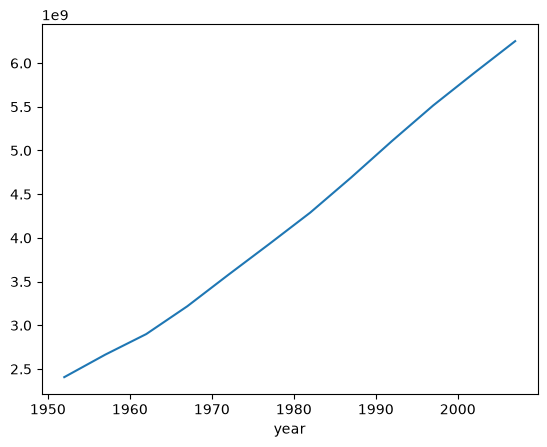

In [105]:
# Opción 1
# Usamos la función plot de series de pandas
pobAnual.plot()

<Axes: xlabel='year'>

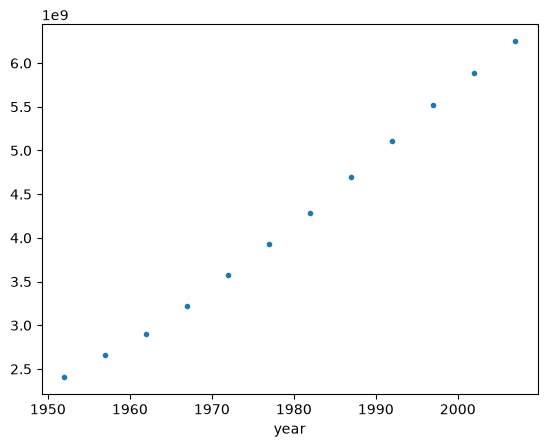

In [106]:
# O podemos graficar solo puntos
pobAnual.plot(style = ".")

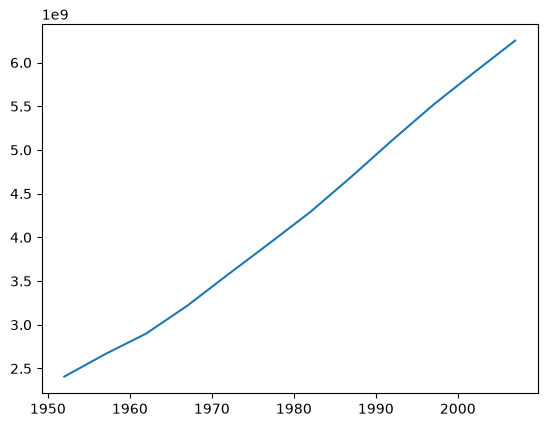

In [107]:
# Opcion 3
# Asignamos los valores a variables (arrays de numpy) y graficamos las variables
x = pobAnual.index
y = pobAnual.values
plt.plot(x,y)

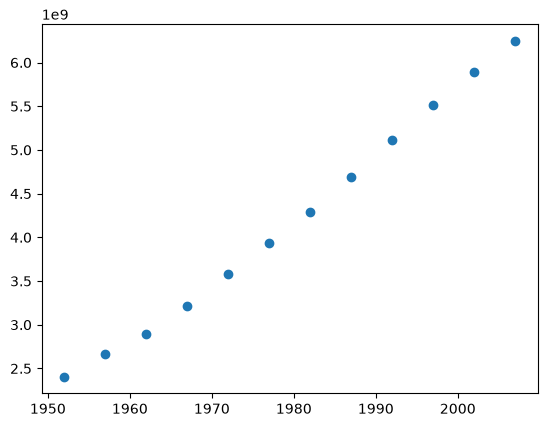

In [108]:
# Opcion 4
# Matplotlib tiene una función scatter para graficar puntos
plt.scatter(x,y)

In [109]:
# Vamos a analizar los datos de 2007
datos2007 = gapminder[gapminder["year"]==2007]

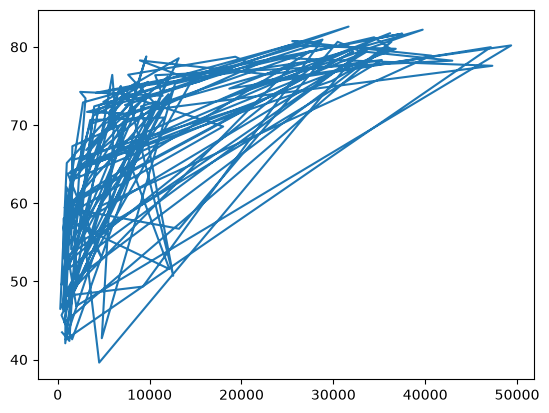

In [110]:
# Queremos ver si hay relación entre el producto bruto y la expectativa de vida
plt.plot(datos2007.gdpPercap, datos2007.lifeExp)

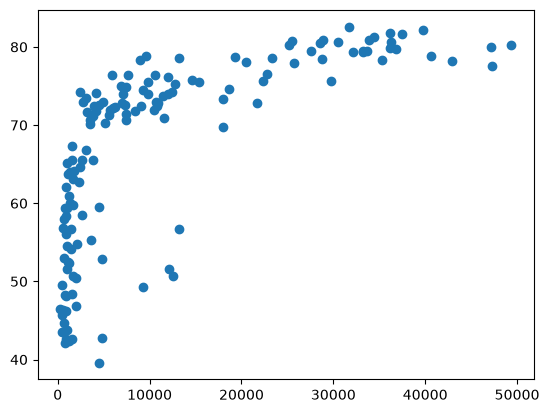

In [111]:
# Ay no, eso no, hacemos un "scatter plot"
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.show()

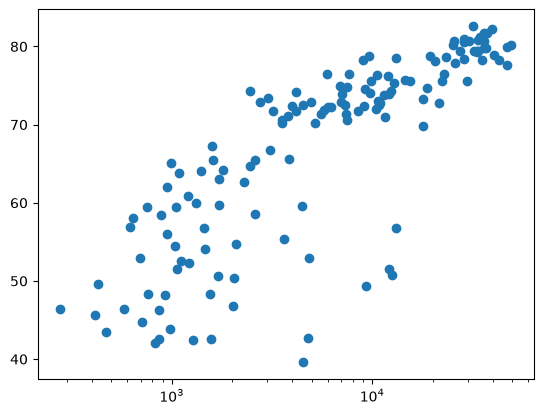

In [112]:
# Se ve mejor la correlación si usamos escala logaritmica en el eje X
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')

Vamos a mejorar un poco el gráfico

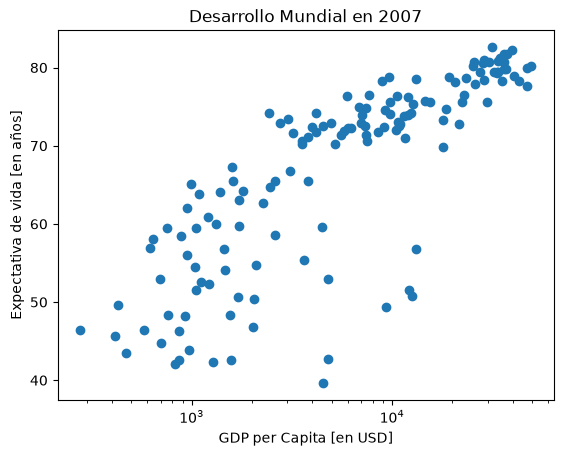

In [113]:
# Agregamos etiquetas al gráfico y a los ejes
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.show()

Reemplacemos las marcas en el eje $x$ 10³, 10⁴, 10⁵ con 1k, 10k y 100k. 

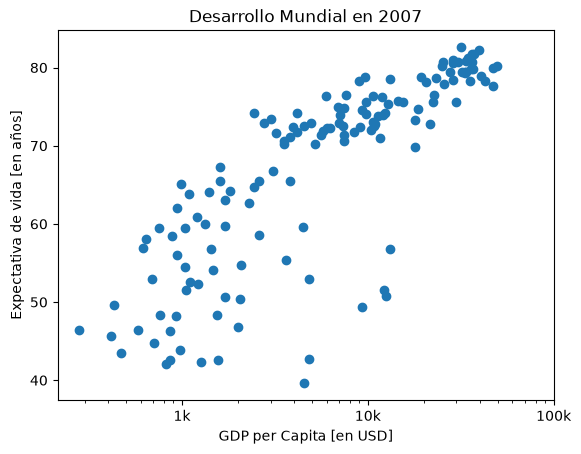

In [114]:
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

Seaborn es una biblioteca para visualización de datos en Python, basada en Matplotlib que agrega muchas funcioanlidades.

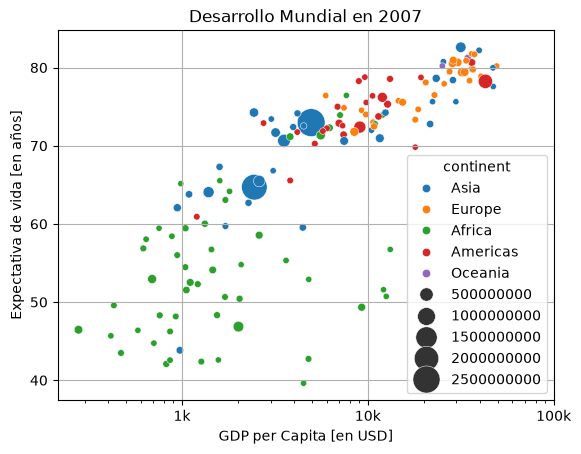

In [115]:
# Usamos scatterplot de seaborn para poder personalizar mejor el grafico

# Almacenamos la población como un array de numpy: np_pop
np_pop = np.array(datos2007["pop"])

sns.scatterplot(x = datos2007['gdpPercap'], y = datos2007['lifeExp'], hue = datos2007['continent'], size = np_pop*2, sizes=(20,400))
plt.grid(True)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

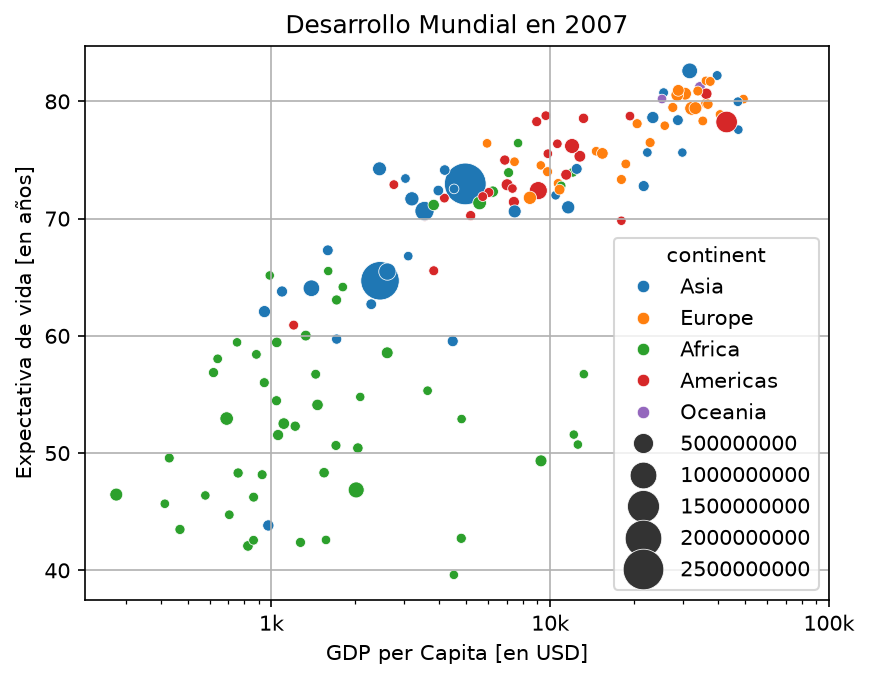

In [116]:
# Aumenta el tamaño del gráfico
plt.figure(dpi=150)

# Almacenamos la población como un array de numpy: np_pop
np_pop = np.array(datos2007["pop"])
np_pop2 = np_pop*2

# Usamos scatterplot de seaborn para poder personalizar mejor el grafico
sns.scatterplot(x = datos2007['gdpPercap'], y = datos2007['lifeExp'], hue = datos2007['continent'], size = np_pop2, sizes=(20,400))
plt.grid(True)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

## Estadística descriptiva

In [5]:
# Vamos a analizar los datos de 2007
datos2007 = gapminder[gapminder["year"]==2007]
datos2007

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [123]:
# Queremos usar los países como índices
datos2007.set_index("country")

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [124]:
# Funcionó? -> No porque no lo hace sobre el dataframe original
datos2007 

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [125]:
# Para guardar los cambios, lo asignamos a la misma variable
datos2007 = datos2007.set_index("country")
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [126]:
# O usamos la opcion inplace = True
datos2007 = gapminder[gapminder["year"]==2007]
datos2007.set_index("country", inplace = True)
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [5]:
# O por último, hacemos todo en una sola linea (opcion recomendada)
datos2007 = gapminder[gapminder["year"]==2007].set_index("country")
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


Mirando los datos de 2007, ¿cuál es el país con mayor expectativa de vida? ¿Cuál es el país con menor expectativa de vida?

In [134]:
datos2007["lifeExp"].max() # Me va a devolver el mayor valor de la serie, pero sin ninguna información más.

np.float64(82.603)

In [138]:
np.argmax(datos2007["lifeExp"]) # Me va a devolver la posición de la fila con el valor más alto dentro de la serie que indiqué

np.int64(66)

In [137]:
datos2007.iloc[np.argmax(datos2007["lifeExp"])] # Puedo usar.iloc para ubicar el pais que estoy buscando a partir de la posición que me devuelve np.argmax

year                2007
pop          127467972.0
continent           Asia
lifeExp           82.603
gdpPercap    31656.06806
Name: Japan, dtype: object

En matemática, cuando queremos saber para qué valor se alcanza el máximo, decimos que queremos saber el "argumento" del máximo. Esta funcion suele llamarse `argmax`. Utilizar la función de numpy np.argmax para responder las preguntas.

La función de numpy devuelve la posición. Si queremos saber el índice, podemos usar el método de series de Panda idxmax().

In [141]:
datos2007["lifeExp"].idxmax() # Ahora si, me devuelve el indice (con la etiqueta, no una posición numérica) del dato cuyo valor buscado es el mayor de la serie

'Japan'

### Medidas de tendencia central

Para el año 2007, calcular el valor medio y la mediana de las variables gdpPercap y lifeExp entre todos los países.
Son similares o distintas? A qué lo atribuyen? Consideran que alguna resume mejor la realidad que la otra?


- En el caso de gdpPercap, va a ser mas representativa de la realidad la mediana (.median()). Esto es así porque la distribución de valores es muy asimetrica: existen pocos paises con un gdpPercap muy alto y muchos paises con un gdpPercap muy bajo. Si hiciera un promedio (.mean()), los valores de gdpPercap muy altos de pocos paises inflarían el promedio, obteniendo asi una visión sesgada.
- En el caso de lifeExp, si puedo usar el promedio (.mean()), porque la distribución de valores está más acotada en un rango razonable de edades (no es como en gdpPercap que puedo tener un pais con un gdpPercap de 100000 y otro con uno de 400)

In [142]:
datos2007["lifeExp"].median()

np.float64(71.93549999999999)

In [143]:
datos2007["lifeExp"].mean()

np.float64(67.00742253521126)

In [144]:
datos2007["gdpPercap"].median()

np.float64(6124.3711084999995)

In [6]:
datos2007["gdpPercap"].mean() # --> Me va a dar un resultado al alza porque tengo pocos paises que tienen un gdpPercap muy alto, haciendo que el promedio se sesgue.

np.float64(11680.071819878167)

¿Es lo mismo el promedio de la expectativa de vida entre todos los países y el promedio de la expectativa de vida entre todas las personas?
¿Cuál calculamos arriba? ¿Cómo podemos calcular el otro?


In [17]:
# Promedio de expectativa de vida entre todos los paises
print(datos2007["lifeExp"].mean())

67.00742253521126


In [18]:
# Promedio de expectativa de vida entre todas las personas
datos2007["lifeExp_x_pop"] = datos2007["lifeExp"] * datos2007["pop"] # creo una columna en donde va a estar el resultado de lifeExp de un pais por su pop
print(datos2007["lifeExp_x_pop"].sum() / datos2007["pop"].sum()) # sumo todos los valores de la nueva columna y la divido por la suma de todas las personas

68.91909251904043


### Medidas de dispersión

Para el año 2007, calcular la varianza y el desvío estándar de las variables gdpPercap y lifeExp entre todos los países. ¿Cuál es más fácil de interpretar?

In [19]:
datos2007["lifeExp"].var()

np.float64(145.7578240471481)

In [21]:
datos2007["lifeExp"].std()

np.float64(12.07302050222512)

In [6]:
datos2007["gdpPercap"].var()

np.float64(165377988.32242855)

In [7]:
datos2007["gdpPercap"].std()

np.float64(12859.937337422316)

Es mas facil de interpretar el desvío estandar ya que está en las _"mismas unidades"_ que los datos. El desvío estandar lo puedo interpretar como el mas/menos de cuanto se desvían los datos de la media.